<center>
<img src="https://supportvectors.ai/logo-poster-transparent.png" width=400px style="opacity:0.8">
</center>

# Adjacency Matrix and Personalized PageRank

MemGraphRAG retrieval seeds a heterogeneous graph and propagates importance with PPR:

$$\mathbf{v}^{(k+1)} = (1-\lambda)\mathbf{W}\mathbf{v}^{(k)} + \lambda\mathbf{v}^{(0)}$$

where $\mathbf{W}$ is the row-normalized transition matrix derived from the adjacency matrix.

In [1]:
%run supportvectors-common.ipynb



<div style="color:#aaa;font-size:8pt">
<hr/>
&copy; SupportVectors. All rights reserved. <blockquote>This notebook is the intellectual property of SupportVectors, and part of its training material. 
Only the participants in SupportVectors workshops are allowed to study the notebooks for educational purposes currently, but is prohibited from copying or using it for any other purposes without written permission.

<b> These notebooks are chapters and sections from Asif Qamar's textbook that he is writing on Data Science. So we request you to not circulate the material to others.</b>
 </blockquote>
 <hr/>
</div>



In [2]:

import numpy as np
from memg_concepts.adjacency import build_adjacency_matrix
from memg_concepts.config import DEFAULT_PDF
from memg_concepts.pipeline import build_index
from memg_concepts.retrieval import retrieve

index = build_index(DEFAULT_PDF, max_chunks=10, schema_freq_threshold=1)
matrices = build_adjacency_matrix(index.graph)
print('Memory:', index.memory.summary(min_schema_freq=index.schema_freq_threshold))
print('Graph:', index.graph.summary())
print('Nodes:', len(matrices.node_ids))
print('Adjacency shape:', matrices.adjacency.shape)
print('Non-zero adjacency entries:', np.count_nonzero(matrices.adjacency))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Memory: {'passages': 10, 'schemas': 83, 'stable_schemas': 83, 'facts': 115, 'active_facts': 115}
Graph: {'nodes': 213, 'edges': 750, 'type': 12, 'entity': 108, 'passage': 10, 'schema': 83}
Nodes: 213
Adjacency shape: (213, 213)
Non-zero adjacency entries: 988


In [3]:
from memg_concepts.models import NodeKind

df = matrices.to_dataframe()

# Nodes are ordered passages first, then schemas/types/entities.
# Passages never connect directly to other passages — only to entities via evidence edges.
print('Passage × passage block (first 8×8) — expected all zeros:')
display(df.iloc[:8, :8])

passage_ids = [nid for nid in matrices.node_ids if index.graph.nodes[nid].kind == NodeKind.PASSAGE][:4]
entity_ids = [nid for nid in matrices.node_ids if index.graph.nodes[nid].kind == NodeKind.ENTITY][:4]
print('Passage × entity block — non-zero where evidence links exist:')
df.loc[passage_ids, entity_ids]

Passage × passage block (first 8×8) — expected all zeros:


,p_0000,p_0001,p_0002,p_0003,p_0004,p_0005,p_0006,p_0007
p_0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_0007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Passage × entity block — non-zero where evidence links exist:


,ent:google,ent:reproduce_tables_and_figures,ent:proper_attribution,ent:journalistic_or_scholarly_works
p_0000,2.4,0.8,0.8,0.8
p_0001,0.0,0.0,0.0,0.0
p_0002,0.0,0.0,0.0,0.0
p_0003,0.0,0.0,0.0,0.0


## Transition Matrix

Each row of the adjacency matrix is normalized by out-degree to obtain the random-walk transition matrix $\mathbf{W}$.

In [4]:
row_sums = matrices.transition.sum(axis=1)
print('Row sums (should be ~1):', row_sums[:8])

query = 'How does multi-head attention work?'
evidence = retrieve(query, index.memory, index.graph, index.embedder)
top = sorted(evidence.scores.items(), key=lambda x: x[1], reverse=True)[:10]
for node_id, score in top:
    label = index.graph.nodes[node_id].label
    kind = index.graph.nodes[node_id].kind.value
    print(f'{score:.4f} [{kind}] {node_id}: {label[:70]}')

Row sums (should be ~1): [1.         1.         0.99999994 1.         1.         1.
 1.         1.        ]
0.0870 [passage] p_0008: s, albeit at the cost of reduced effective resolution due to averaging
0.0704 [type] type:concept: concept
0.0579 [entity] ent:multi-head_attention: Multi-Head Attention
0.0572 [entity] ent:self-attention: Self-attention
0.0535 [entity] ent:intra-attention: intra-attention
0.0493 [entity] ent:attention_mechanism_relating_different_positions_of_a_single_sequence: attention mechanism relating different positions of a single sequence
0.0476 [entity] ent:attention_mechanism: attention mechanism
0.0469 [entity] ent:recurrent_attention_mechanism: recurrent attention mechanism
0.0427 [passage] p_0003: dot-product attention, multi-head attention and the parameter-free pos
0.0427 [passage] p_0005: ligning the positions to steps in computation time, they generate a se


## Multi-Layer Reset Vectors

MemGraphRAG seeds PPR from three query-aware layers before propagation:

- **$P_{init}(p)$** — passage embedding similarity
- **$P_{init}(e)$** — entity embedding similarity (hub-suppressed)
- **$P_{init}(t)$** — type nodes linked to schema matches

The combined reset is $\mathbf{v}^{(0)} = \mathrm{normalize}(P_{init}(p) + P_{init}(e) + P_{init}(t) + P_{init}(schema))$.

In [5]:
import pandas as pd
from memg_concepts.models import NodeKind
from memg_concepts.pagerank import normalize_reset
from memg_concepts.retrieval import (
    build_query_init_vectors,
    propagation_history_table,
    run_lambda_sweep,
    summarize_scores_by_kind,
)

query = 'How does multi-head attention work?'
inits = build_query_init_vectors(query, index.memory, index.graph, index.embedder, matrices)

entity_count = sum(1 for node in index.graph.nodes.values() if node.kind == NodeKind.ENTITY)
print(f'Entity nodes in graph: {entity_count}')
if entity_count == 0:
    print(
        'P_init(e) is empty because the graph has no entity nodes. '
        'That happens when active_facts is 0 — usually LLM extraction failed or '
        'no facts survived conflict resolution. Re-run the build_index cell and '
        'check Memory summary above.'
    )


def init_table(layer, kind: NodeKind) -> pd.DataFrame:
    rows = []
    for node_id, idx in matrices.node_index().items():
        node = index.graph.nodes[node_id]
        if node.kind != kind:
            continue
        score = float(layer[idx])
        if score <= 0:
            continue
        rows.append({'node_id': node_id, 'label': node.label, 'score': score})
    if not rows:
        return pd.DataFrame(columns=['node_id', 'label', 'score'])
    return pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)


print('P_init(p) — passages')
display(init_table(inits.passage, NodeKind.PASSAGE))
print('P_init(e) — entities')
display(init_table(inits.entity, NodeKind.ENTITY))
print('P_init(t) — types')
display(init_table(inits.type, NodeKind.TYPE))

v0 = normalize_reset(inits.combined)
print('Combined v^(0) mass by kind:', summarize_scores_by_kind(v0, index.graph, inits.node_ids))

Entity nodes in graph: 108
P_init(p) — passages


,node_id,label,score
0,p_0008,"s, albeit at the cost of reduced effective res...",0.481729
1,p_0003,"dot-product attention, multi-head attention an...",0.400443
2,p_0005,ligning the positions to steps in computation ...,0.362193
3,p_0002,"translation task, our model establishes a new ...",0.359115
4,p_0009,rence and have been shown to perform well on s...,0.334009


P_init(e) — entities


,node_id,label,score
0,ent:intra-attention,intra-attention,0.500068
1,ent:multi-head_attention,Multi-Head Attention,0.476159
2,ent:attention_mechanism,attention mechanism,0.465597
3,ent:attention_mechanism_relating_different_pos...,attention mechanism relating different positio...,0.456198
4,ent:recurrent_attention_mechanism,recurrent attention mechanism,0.437988
5,ent:due_to_averaging_attention-weighted_positions,due to averaging attention-weighted positions,0.395317
6,ent:attention_mechanisms,attention mechanisms,0.297901
7,ent:self-attention,Self-attention,0.224271


P_init(t) — types


,node_id,label,score


Combined v^(0) mass by kind: {'type': 0.0, 'entity': 0.62675917694984, 'passage': 0.37324082305016, 'schema': 0.0}


## Lambda Sweep — 10 Propagation Steps

Iterate $\mathbf{v}^{(k+1)} = (1-\lambda)\mathbf{W}\mathbf{v}^{(k)} + \lambda\mathbf{v}^{(0)}$ for $\lambda \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$ and track how probability mass flows across passages, entities, types, and schemas.

,lambda,step,type,entity,passage,schema
0,0.1,0,0.000000,0.626759,0.373241,0.000000
1,0.1,1,0.192237,0.616650,0.191114,0.000000
2,0.1,2,0.194950,0.531876,0.193284,0.079890
3,0.1,3,0.239591,0.511598,0.171476,0.077334
4,0.1,4,0.231069,0.505743,0.166499,0.096689
5,0.1,5,0.246319,0.497350,0.164763,0.091568
6,0.1,6,0.239061,0.500195,0.162644,0.098100
7,0.1,7,0.245681,0.496686,0.163237,0.094395
8,0.1,8,0.241218,0.499354,0.162334,0.097095
9,0.1,9,0.244414,0.497721,0.162947,0.094918


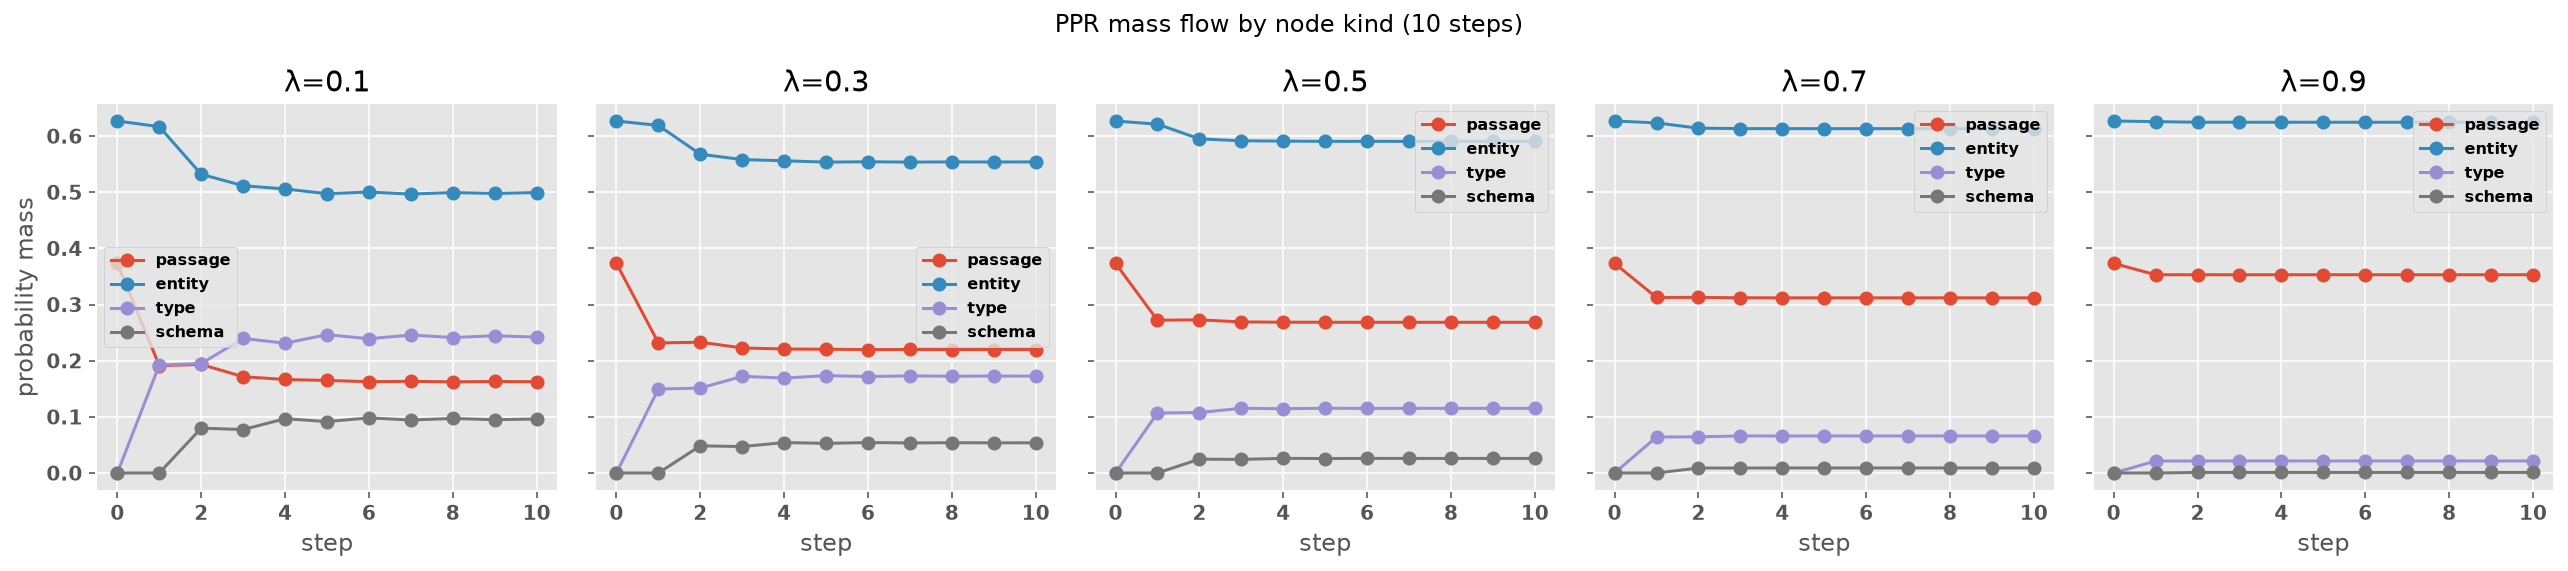

In [6]:
from matplotlib import pyplot as plt
lambdas = (0.1, 0.3, 0.5, 0.7, 0.9)
num_steps = 10
sweeps = run_lambda_sweep(matrices, inits.combined, lambdas=lambdas, num_steps=num_steps)

mass_rows = []
for damping, history in sweeps.items():
    for step, scores in enumerate(history):
        totals = summarize_scores_by_kind(scores, index.graph, inits.node_ids)
        mass_rows.append({'lambda': damping, 'step': step, **totals})
mass_df = pd.DataFrame(mass_rows)

fig, axes = plt.subplots(1, len(lambdas), figsize=(18, 4), sharey=True)
for ax, damping in zip(axes, lambdas):
    subset = mass_df[mass_df['lambda'] == damping]
    for kind in ['passage', 'entity', 'type', 'schema']:
        if kind in subset.columns:
            ax.plot(subset['step'], subset[kind], marker='o', label=kind)
    ax.set_title(f'λ={damping}')
    ax.set_xlabel('step')
    ax.legend(fontsize=8)
axes[0].set_ylabel('probability mass')
plt.suptitle(f'PPR mass flow by node kind ({num_steps} steps)')
plt.tight_layout()

mass_df

In [7]:
# Top nodes after 10 steps at λ=0.5 (passages, entities, types)
propagation_history_table(
    sweeps[0.5],
    index.graph,
    inits.node_ids,
    kinds=(NodeKind.PASSAGE, NodeKind.ENTITY, NodeKind.TYPE),
).sort_values('step_10', ascending=False).head(20)

,node_id,kind,label,step_0,step_1,step_2,step_3,step_4,step_5,step_6,step_7,step_8,step_9,step_10
8,p_0008,passage,"s, albeit at the cost of reduced effective res...",0.092801,0.101578,0.088483,0.088361,0.087302,0.087204,0.087082,0.087063,0.087046,0.087042,0.087040
11,type:concept,type,concept,0.000000,0.082703,0.063703,0.072351,0.069765,0.070673,0.070322,0.070423,0.070374,0.070386,0.070379
115,ent:multi-head_attention,entity,Multi-Head Attention,0.091728,0.052493,0.061323,0.057543,0.058319,0.057848,0.057930,0.057867,0.057875,0.057867,0.057867
118,ent:self-attention,entity,Self-attention,0.043204,0.069803,0.057460,0.058375,0.057324,0.057351,0.057218,0.057211,0.057192,0.057190,0.057187
119,ent:intra-attention,entity,intra-attention,0.096334,0.053024,0.054543,0.053576,0.053631,0.053547,0.053548,0.053538,0.053537,0.053535,0.053535
120,ent:attention_mechanism_relating_different_pos...,entity,attention mechanism relating different positio...,0.087883,0.048799,0.050317,0.049350,0.049405,0.049322,0.049322,0.049312,0.049311,0.049310,0.049310
100,ent:attention_mechanism,entity,attention mechanism,0.089693,0.047778,0.048002,0.047561,0.047593,0.047571,0.047574,0.047573,0.047573,0.047573,0.047573
123,ent:recurrent_attention_mechanism,entity,recurrent attention mechanism,0.084375,0.045502,0.048008,0.046970,0.047004,0.046922,0.046918,0.046909,0.046907,0.046906,0.046906
3,p_0003,passage,"dot-product attention, multi-head attention an...",0.077142,0.038571,0.043349,0.042422,0.042641,0.042667,0.042692,0.042705,0.042709,0.042712,0.042713
5,p_0005,passage,ligning the positions to steps in computation ...,0.069773,0.039794,0.043954,0.042777,0.042725,0.042703,0.042676,0.042677,0.042672,0.042672,0.042672


PPR spreads query relevance along fact, schema, and evidence edges so globally important passages rise even when direct embedding similarity is weak.